<a id='notebook-top'></a>
This notebook demonstrates the observations made by key instruments,e.g., DKIST/VBI, SolO/EUI, and IRIS
during the DKIST-SolO cooridinated observation campaign in Oct. 2022. This campagin would not be possible without the 
support from both DKIST and Solar Orbiter teams, including using the director discretionary time of DKIST. Many thanks 
to K. Barczynski, T. Schad, M. Janiver, C. Nelson, A. Tritschler, D. Müller, and other DKIST, Solar Orbiter, IRIS, and 
Hinode team members and planners to make it happen. Barczynski et al. 2025 summarizes the 2022 campaign.

The FOVs of the key observations analyzed in this study are presented in [Figure 1](#figure-1). 

Note: The internal hyperlink only works on [GitHub Pages](https://yjzhu-solar.github.io/DKIST_SolO_Fibril/ipynb_html/fov_summary.html) or [nbviewer](https://nbviewer.org/github/yjzhu-solar/DKIST_SolO_Fibril/blob/master/ipynb/ms_plot/fov_summary.ipynb). Do not click when viewing the notebook on GitHub.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.patheffects as path_effects
import sunpy.map 
import astropy.units as u
import astropy.constants as const 
from astropy.time import Time
from sunpy.map import make_fitswcs_header
from sunpy.coordinates import propagate_with_solar_surface
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.visualization import ImageNormalize, AsinhStretch
from astropy.io import fits
from sjireader import read_iris_sji
from itertools import chain
from glob import glob
from IPython.display import HTML, display

In [2]:
ms_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                 'xtick.major.width': 1.2, 'xtick.major.size': 4,
                 'ytick.major.width': 1.2, 'ytick.major.size': 4,
                 'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                 'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                 'xtick.direction': 'in', 'ytick.direction': 'in',
                 'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                 r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                 r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}'}

In [3]:
fsi_174_map = sunpy.map.Map("../../data/pid_1_123_aux/FSI/solo_L2_eui-fsi174-image_20221024T191050177_V01.fits")
fsi_174_map = fsi_174_map.rotate()

In [4]:
print(fsi_174_map.meta['date_ear'])

2022-10-24T19:15:55.439


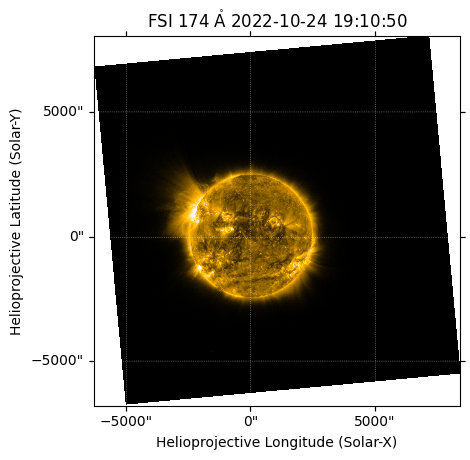

In [5]:
fsi_174_map.plot()

In [6]:
aia_171_map = sunpy.map.Map("../../data/pid_1_123_aux/AIA/171/aia.lev1_euv_12s.2022-10-24T191603Z.171.image.fits")
aia_171_map.meta["rsun_ref"] = fsi_174_map.meta["rsun_ref"]
aia_171_map_crop = aia_171_map.submap(SkyCoord(-600*u.arcsec, 50*u.arcsec, frame=aia_171_map.coordinate_frame),
                top_right=SkyCoord(-200*u.arcsec, 450*u.arcsec, frame=aia_171_map.coordinate_frame))

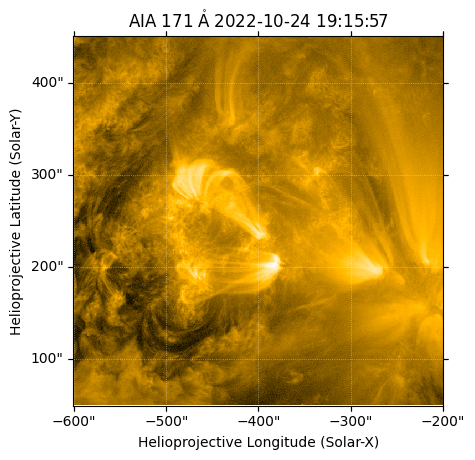

In [7]:
aia_171_map_crop.plot()

In [8]:
print(aia_171_map_crop.bottom_left_coord, aia_171_map_crop.top_right_coord)

<SkyCoord (Helioprojective: obstime=2022-10-24T19:15:58.353, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-10-24T19:15:58.353, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.00125392, 5.1048738, 1.48766353e+11)>): (Tx, Ty) in arcsec
    (-600.29832916, 50.09978885)> <SkyCoord (Helioprojective: obstime=2022-10-24T19:15:58.353, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2022-10-24T19:15:58.353, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.00125392, 5.1048738, 1.48766353e+11)>): (Tx, Ty) in arcsec
    (-200.09994523, 450.29909075)>


In [9]:
aia_171_map_crop.data.shape

(668, 668)

In [10]:
print(fsi_174_map.wcs.world_to_pixel(aia_171_map_crop.bottom_left_coord),
fsi_174_map.wcs.world_to_pixel(aia_171_map_crop.top_right_coord))

(array(1536.9846273), array(1534.47139858)) (array(1697.51881488), array(1783.48822533))


In [11]:
fsi_174_map_crop = fsi_174_map.submap([1535, 1552]*u.pix,
                    top_right=[1535+220, 1552+220]*u.pix)

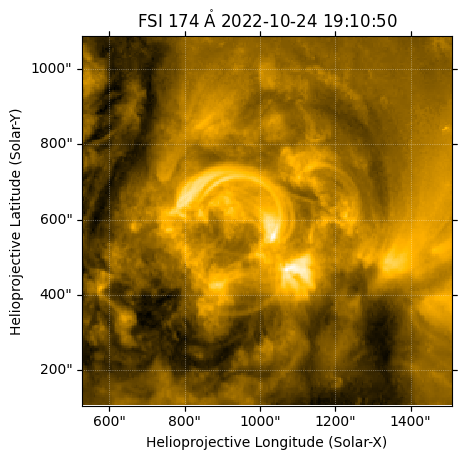

In [12]:
fsi_174_map_crop.plot()

In [13]:
hrt_blos_map = sunpy.map.Map("../../data/pid_1_123_aux/HRT/phi_los_map_shifted_for_pore.fits")

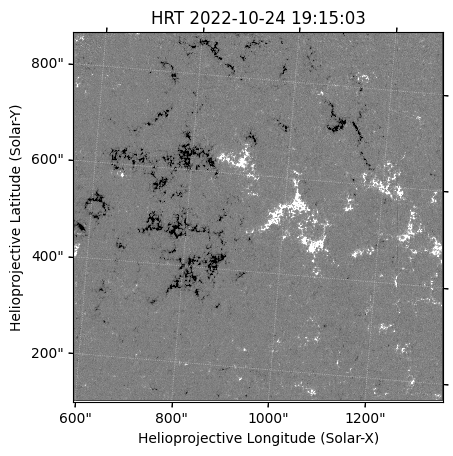

In [14]:
hrt_blos_map.plot(vmin=-200, vmax=200)

In [15]:
hrt_repro_nx = np.round((fsi_174_map_crop.top_right_coord.Tx - fsi_174_map_crop.bottom_left_coord.Tx).to(u.arcsec)/ \
                         hrt_blos_map.scale.axis1.to(u.arcsec/u.pix)).to_value(u.pix).astype(int)
hrt_repro_center_coord = SkyCoord(
    fsi_174_map_crop.center.Tx,
    fsi_174_map_crop.center.Ty,
    frame=hrt_blos_map.coordinate_frame
) 
hrt_repro_header = make_fitswcs_header(
    data=(hrt_repro_nx, hrt_repro_nx),
    coordinate=hrt_repro_center_coord,
    scale=u.Quantity([hrt_blos_map.scale.axis1, hrt_blos_map.scale.axis2]),
)

In [16]:
hrt_blos_map_repro = hrt_blos_map.reproject_to(WCS(hrt_repro_header), algorithm="adaptive")

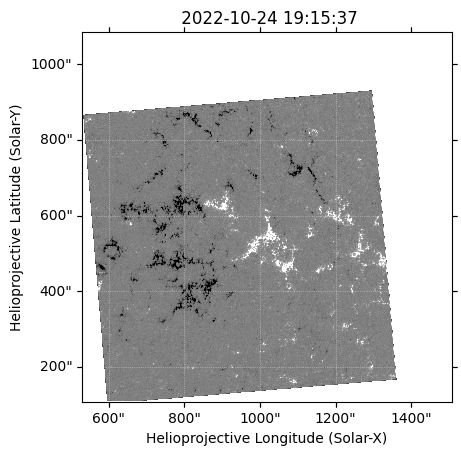

In [17]:
hrt_blos_map_repro.plot(vmin=-200, vmax=200)

In [18]:
Time(hrt_blos_map.meta['date_ear']).tai

<Time object: scale='tai' format='isot' value=2022-10-24T19:20:40.490>

In [19]:
hmi_blos_map = sunpy.map.Map("../../data/pid_1_123_aux/HMI/hmi.M_45s.20221024_192100_TAI.2.magnetogram.fits")
hmi_blos_map.meta["rsun_ref"] = fsi_174_map.meta["rsun_ref"]

In [20]:
hmi_blos_map_crop = hmi_blos_map.submap(aia_171_map_crop.bottom_left_coord,
                top_right=aia_171_map_crop.top_right_coord)

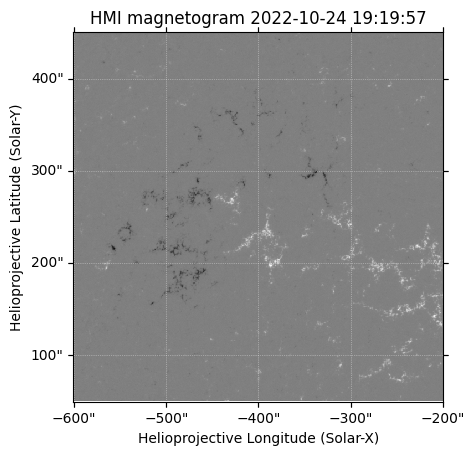

In [21]:
hmi_blos_map_crop.plot()

In [22]:
TiO_ds_raw_header_0 = fits.getheader("../../data/pid_1_123/BNRPZ/VBI_2022_10_24T18_58_12_753_00705800_I_BNRPZ_L1.fits", ext=1)
TiO_ds_raw_header_0["CDELT1"] = TiO_ds_raw_header_0["CDELT1"]*1.1075
TiO_ds_raw_header_0["CDELT2"] = TiO_ds_raw_header_0["CDELT2"]*1.1075
TiO_ds_raw_header_0["CRVAL1"] = TiO_ds_raw_header_0["CRVAL1"] - 13 + \
    (-140.1 - 15.2)*TiO_ds_raw_header_0["CDELT1"]*TiO_ds_raw_header_0["PC1_1"] + \
    (-125.1)*TiO_ds_raw_header_0["CDELT2"]*TiO_ds_raw_header_0["PC1_2"] + 4.4
TiO_ds_raw_header_0["CRVAL2"] = TiO_ds_raw_header_0["CRVAL2"] - 15 + \
    (-140.1 - 15.2)*TiO_ds_raw_header_0["CDELT1"]*TiO_ds_raw_header_0["PC2_1"] + \
    (-125.1)*TiO_ds_raw_header_0["CDELT2"]*TiO_ds_raw_header_0["PC2_2"] + 1.46 # crude estimation
TiO_ds_raw_header_0.remove("NAXIS3")

TiO_ds_wcs = WCS(TiO_ds_raw_header_0, naxis=2)
TiO_dummp_map = sunpy.map.Map(np.zeros((4096, 4096)), TiO_ds_wcs)

Set MJD-BEG to 59876.790425 from DATE-BEG.
Set MJD-AVG to 59876.790425 from DATE-AVG.
Set MJD-END to 59876.790425 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [23]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)
Gband_dummp_map = sunpy.map.Map(np.zeros((4096, 4096)), WCS(dkist_vbi_target_header))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]


In [24]:
iris_sji_1400_cube = read_iris_sji("../../data/pid_1_123_aux/IRIS/iris_l2_20221024_190447_3643101203_SJI_1400_t000.fits",
                                sdo_rsun=False)

In [25]:
dkist_fitv_tom_btot_map_shift = sunpy.map.Map("../../data/pid_1_123/BKEWK/dkist_fitv_tom_btot_map_shift.fits")

In [26]:
hri_files = sorted(glob("../../data/pid_1_123_aux/HRI/coalign_step_boxcar/*.fits"))
hri_map_181 = sunpy.map.Map(hri_files[181])
Txshift_hri, Tyshift_hri = (1.66986 + 2.49223)*u.arcsec,(7.60204 - 2.76366 - 1.0 )*u.arcsec
hri_map_181 = hri_map_181.shift_reference_coord(Txshift_hri,Tyshift_hri)

In [27]:
def get_map_edge_coords(map, step=1):
    map_edges = sunpy.map.map_edges(map)

    x_pix = []
    y_pix = []

    if map_edges[1].shape[0] % step != 0:
        iter_1 = chain(range(0, map_edges[1].shape[0], step), [map_edges[1].shape[0]-1])
    else:
        iter_1 = range(0, map_edges[1].shape[0], step)
    for ii in iter_1:
        x_pix.append(map_edges[1][ii,0].value)
        y_pix.append(map_edges[1][ii,1].value)

    if map_edges[3].shape[0] % step != 0:
        iter_3 = chain(range(0, map_edges[3].shape[0], step), [map_edges[3].shape[0]-1])
    else:
        iter_3 = range(0, map_edges[3].shape[0], step)

    for ii in iter_3:
        x_pix.append(map_edges[3][ii,0].value)
        y_pix.append(map_edges[3][ii,1].value)

    if map_edges[0].shape[0] % step != 0:
        iter_0 = chain(range(map_edges[0].shape[0]-1, -1, -step), [0])
    else:
        iter_0 = range(map_edges[0].shape[0]-1, -1, -step)

    for ii in iter_0:
        x_pix.append(map_edges[0][ii,0].value)
        y_pix.append(map_edges[0][ii,1].value)

    if map_edges[2].shape[0] % step != 0:
        iter_2 = chain(range(map_edges[2].shape[0]-1, -1, -step), [0])
    else:
        iter_2 = range(map_edges[2].shape[0]-1, -1, -step)

    for ii in iter_2:
        x_pix.append(map_edges[2][ii,0].value)
        y_pix.append(map_edges[2][ii,1].value)
    
    return map.pixel_to_world(x_pix*u.pix,y_pix*u.pix)

In [28]:
dkist_fitv_tom_btot_map_shift.data.shape

(2555, 688)

In [29]:
TiO_map_edges = get_map_edge_coords(TiO_dummp_map, step=64)
Gband_map_edges = get_map_edge_coords(Gband_dummp_map, step=64)
iris_map_edges = get_map_edge_coords(iris_sji_1400_cube[0], step=2)
visp_map_edges = get_map_edge_coords(dkist_fitv_tom_btot_map_shift, step=64)
hri_map_edges = get_map_edge_coords(hri_map_181, step=32)

INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


For frame 'heliographic_stonyhurst' the following metadata is missing: dsun_obs,hgln_obs,hglt_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crlt_obs,crln_obs
 [sunpy.map.mapbase]
For frame 'heliographic_stonyhurst' the following metadata is missing: dsun_obs,hgln_obs,hglt_obs
For frame 'heliographic_carrington' the following metadata is missing: dsun_obs,crlt_obs,crln_obs
 [sunpy.map.mapbase]


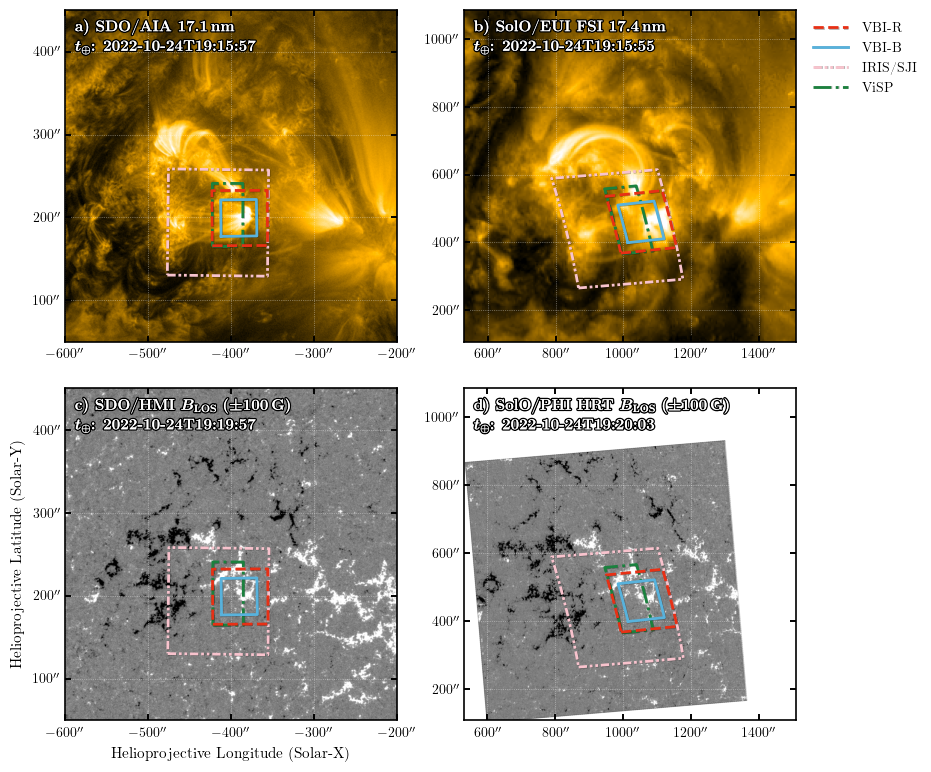

In [30]:
display(HTML('<a href="#notebook-top">Go to top</a>'))
display(HTML('<a id="figure-1"></a>'))

with plt.rc_context(ms_style_dict):
    
    fig = plt.figure(figsize=(9.2,7.8), layout="constrained")

    # reference_ax = fig.add_axes([0,0,1,1])
    # reference_ax.set_zorder(15)

    # reference_ax.grid("on",zorder=5, alpha=0.4)
    # reference_ax.patch.set_alpha(0.2)
    # reference_ax.axhline(0.76, color="red", alpha=0.4)
    # reference_ax.axhline(0.725, color="red", alpha=0.4)
    # reference_ax.axhline(0.35, color="red", alpha=0.4)

    ax1 = fig.add_subplot(221,projection=aia_171_map_crop)
    aia_171_map_crop.plot(axes=ax1,
            title=None,
            norm=ImageNormalize(
                vmin=np.nanpercentile(aia_171_map_crop.data, 0.01),
                vmax=np.nanpercentile(aia_171_map_crop.data, 99.9),
                stretch=AsinhStretch(0.06),
            ),
            interpolation=None, rasterized=True)

    ax2 = fig.add_subplot(222,projection=fsi_174_map_crop)
    fsi_174_map_crop.plot(axes=ax2,
            title=None,
            norm=ImageNormalize(
                vmin=np.nanpercentile(fsi_174_map_crop.data, 0.05),
                vmax=np.nanpercentile(fsi_174_map_crop.data, 99.8),
                stretch=AsinhStretch(0.03),
            ),
            interpolation=None, rasterized=True)

    ax3 = fig.add_subplot(223,projection=hmi_blos_map_crop)
    hmi_blos_map_crop.plot(axes=ax3,
            title=None,
            norm=ImageNormalize(
                vmin=-100,
                vmax=100,
            ),
            interpolation=None, rasterized=True)

    ax4 = fig.add_subplot(224,projection=hrt_blos_map_repro)
    hrt_blos_map_repro.plot(axes=ax4,
            title=None,
            norm=ImageNormalize(
                vmin=-100,
                vmax=100,
            ),
            interpolation=None, rasterized=True)
    

    for ax_ in (ax1,ax2,ax3,ax4):
        with propagate_with_solar_surface():
            ax_.plot_coord(
                TiO_map_edges,
                color="#E83015",
                linewidth=2,
                zorder=10,
                ls="--",
                path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()],
                label=r"VBI-R"
            )

            ax_.plot_coord(
                Gband_map_edges,
                color="#58B2DC",
                linewidth=2,
                zorder=10,
                path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()],
                label=r"VBI-B"

            )
        
            ax_.plot_coord(
                iris_map_edges,
                color="#F8C3CD",
                linewidth=2,
                zorder=8,
                ls=(0, (3, 1, 1, 1, 1, 1)),
                path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()],
                label=r"IRIS/SJI"
            )
        
            ax_.plot_coord(
                visp_map_edges,
                color="#1B813E",
                linewidth=2,
                zorder=8,
                ls="-.",
                path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()],
                label=r"ViSP"
            )

            # ax_.plot_coord(
            #     hri_map_edges,
            #     color="#77428D",
            #     linewidth=2,
            #     zorder=8,
            #     ls="-.",
            #     path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
            #             path_effects.Normal()],
            #     label=r"HRI_{EUV}"
            # )
        
    ax2.legend(fontsize=10,
        bbox_to_anchor=(1.0, 0.6, 0.4, 0.4),
        frameon=False,
        alignment="left",
        handlelength=2.5,
        handletextpad=1)


    for ax_ in (ax1,ax2,ax4):
        ax_.coords[0].set_axislabel("", visible=False, size=0)
        ax_.coords[1].set_axislabel("", visible=False, size=0)
    
    ax3.coords[0].set_axislabel(r"Helioprojective Longitude (Solar-X)", size=11)
    ax3.coords[1].set_axislabel(r"Helioprojective Latitude (Solar-Y)", size=11)
    
    ax1.text(0.03, 0.97,
        r"\textbf{a) SDO/AIA 17.1\,nm}" + \
        "\n" + \
        r"$\boldsymbol{{t_{{\oplus}}}}$\textbf{{: {}}}".format(aia_171_map.meta['date-obs'][:-4]),
        fontsize=11,
        transform=ax1.transAxes,
        va="top",
        ha="left",
        color="white",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="black"),
                      path_effects.Normal()],
        linespacing=1.5,
    )

    ax2.text(0.03, 0.97,
        r"\textbf{b) SolO/EUI FSI 17.4\,nm}" + \
        "\n" + \
        r"$\boldsymbol{{t_{{\oplus}}}}$\textbf{{: {}}}".format(fsi_174_map.meta['date_ear'][:-4]),
        fontsize=11,
        transform=ax2.transAxes,
        va="top",
        ha="left",
        color="white",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="black"),
                      path_effects.Normal()],
        linespacing=1.5,

    )

    ax3.text(0.03, 0.97,
        r"\textbf{c) SDO/HMI $\boldsymbol{B_{\rm LOS}\ (\pm 100\,\mathrm{G})}$}" + \
        "\n" + \
        r"$\boldsymbol{{t_{{\oplus}}}}$\textbf{{: {}}}".format(hmi_blos_map.meta['date-obs'][:-4]),
        fontsize=11,
        transform=ax3.transAxes,
        va="top",
        ha="left",
        color="white",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="black"),
                      path_effects.Normal()],
        linespacing=1.5,
    )

    ax4.text(0.03, 0.97,
        r"\textbf{d) SolO/PHI HRT $\boldsymbol{B_{\rm LOS}\ (\pm 100\,\mathrm{G})}$}" + \
        "\n" + \
        r"$\boldsymbol{{t_{{\oplus}}}}$\textbf{{: {}}}".format(hrt_blos_map.meta['date_ear'][:-4]),
        fontsize=11,
        transform=ax4.transAxes,
        va="top",
        ha="left",
        color="white",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="black"),
                      path_effects.Normal()],
        linespacing=1.5,
    )
    
    
    fig.savefig("../../figs/ms_figure/fov_summary.pdf", bbox_inches='tight', dpi=300)
    fig.savefig("../../figs/ms_figure_png/fov_summary.png", bbox_inches='tight', dpi=300)
    plt.show()


In [31]:
# a dark mode style
dm_fc = "#F3F4F3"
dm_bg = "#2D2F34"
ms_dm_style_dict = {'text.usetex': True, 'font.family': 'serif', 'axes.linewidth': 1.2,
                    'xtick.major.width': 1.2, 'xtick.major.size': 4,
                    'ytick.major.width': 1.2, 'ytick.major.size': 4,
                    'xtick.minor.width': 1.2, 'xtick.minor.size': 2,
                    'ytick.minor.width': 1.2, 'ytick.minor.size': 2,
                    'xtick.direction': 'in', 'ytick.direction': 'in',
                    'text.latex.preamble': r'\usepackage[T1]{fontenc}'
                    r'\usepackage{amsmath}' r'\usepackage{siunitx}'
                    r'\sisetup{detect-all=True}' r'\usepackage{fixltx2e}',
                    'lines.color': dm_fc, 'patch.edgecolor': dm_fc,
                    'text.color': dm_fc, 'axes.facecolor': dm_bg,
                    'axes.edgecolor': dm_fc, 'axes.labelcolor': dm_fc,
                    'axes.prop_cycle': plt.cycler(color=['#8dd3c7', '#feffb3', '#bfbbd9',
                    '#fa8174', '#81b1d2', '#fdb462', '#b3de69', '#bc82bd', '#ccebc4', '#ffed6f']),
                    'xtick.color': dm_fc, 'ytick.color': dm_fc,
                    'grid.color': dm_fc,
                    # 'figure.facecolor': dm_bg, 'figure.edgecolor': dm_bg,
                    # 'savefig.facecolor': dm_bg, 'savefig.edgecolor': dm_bg,
                    'figure.facecolor': "none", 'figure.edgecolor': "none",
                    'savefig.facecolor': "none", 'savefig.edgecolor': "none", 'savefig.transparent': True,
                    'axes.facecolor': "none", #'axes.edgecolor': "none",
                    'boxplot.boxprops.color': dm_fc,
                    'boxplot.capprops.color': dm_fc,
                    'boxplot.whiskerprops.color': dm_fc,
                    'boxplot.flierprops.color': dm_fc,
                    'boxplot.flierprops.markeredgecolor': dm_fc,} 

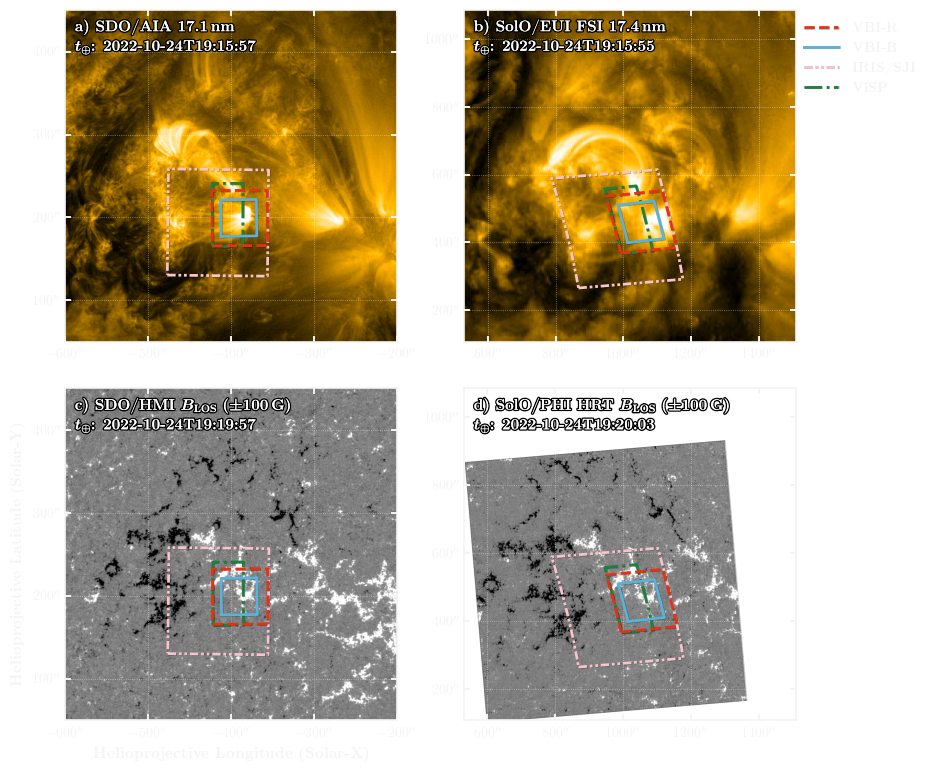

In [32]:
with plt.rc_context(ms_dm_style_dict):
    
    fig = plt.figure(figsize=(9.2,7.8), layout="constrained")

    # reference_ax = fig.add_axes([0,0,1,1])
    # reference_ax.set_zorder(15)

    # reference_ax.grid("on",zorder=5, alpha=0.4)
    # reference_ax.patch.set_alpha(0.2)
    # reference_ax.axhline(0.76, color="red", alpha=0.4)
    # reference_ax.axhline(0.725, color="red", alpha=0.4)
    # reference_ax.axhline(0.35, color="red", alpha=0.4)

    ax1 = fig.add_subplot(221,projection=aia_171_map_crop)
    aia_171_map_crop.plot(axes=ax1,
            title=None,
            norm=ImageNormalize(
                vmin=np.nanpercentile(aia_171_map_crop.data, 0.01),
                vmax=np.nanpercentile(aia_171_map_crop.data, 99.9),
                stretch=AsinhStretch(0.06),
            ),
            interpolation=None, rasterized=True)

    ax2 = fig.add_subplot(222,projection=fsi_174_map_crop)
    fsi_174_map_crop.plot(axes=ax2,
            title=None,
            norm=ImageNormalize(
                vmin=np.nanpercentile(fsi_174_map_crop.data, 0.05),
                vmax=np.nanpercentile(fsi_174_map_crop.data, 99.8),
                stretch=AsinhStretch(0.03),
            ),
            interpolation=None, rasterized=True)

    ax3 = fig.add_subplot(223,projection=hmi_blos_map_crop)
    hmi_blos_map_crop.plot(axes=ax3,
            title=None,
            norm=ImageNormalize(
                vmin=-100,
                vmax=100,
            ),
            interpolation=None, rasterized=True)

    ax4 = fig.add_subplot(224,projection=hrt_blos_map_repro)
    hrt_blos_map_repro.plot(axes=ax4,
            title=None,
            norm=ImageNormalize(
                vmin=-100,
                vmax=100,
            ),
            interpolation=None, rasterized=True)
    

    for ax_ in (ax1,ax2,ax3,ax4):
        with propagate_with_solar_surface():
            ax_.plot_coord(
                TiO_map_edges,
                color="#E83015",
                linewidth=2,
                zorder=10,
                ls="--",
                path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()],
                label=r"\textbf{VBI-R}"
            )

            ax_.plot_coord(
                Gband_map_edges,
                color="#58B2DC",
                linewidth=2,
                zorder=10,
                path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()],
                label=r"\textbf{VBI-B}"

            )
        
            ax_.plot_coord(
                iris_map_edges,
                color="#F8C3CD",
                linewidth=2,
                zorder=8,
                ls=(0, (3, 1, 1, 1, 1, 1)),
                path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()],
                label=r"\textbf{IRIS/SJI}"
            )
        
            ax_.plot_coord(
                visp_map_edges,
                color="#1B813E",
                linewidth=2,
                zorder=8,
                ls="-.",
                path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()],
                label=r"\textbf{ViSP}"
            )

            # ax_.plot_coord(
            #     hri_map_edges,
            #     color="#77428D",
            #     linewidth=2,
            #     zorder=8,
            #     ls="-.",
            #     path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
            #             path_effects.Normal()],
            #     label=r"HRI_{EUV}"
            # )
        
    ax2.legend(fontsize=10,
        bbox_to_anchor=(1.0, 0.6, 0.4, 0.4),
        frameon=False,
        alignment="left",
        handlelength=2.5,
        handletextpad=1)


    for ax_ in (ax1,ax2,ax4):
        ax_.coords[0].set_axislabel("", visible=False, size=0)
        ax_.coords[1].set_axislabel("", visible=False, size=0)

    ax3.coords[0].set_axislabel(r"\textbf{Helioprojective Longitude (Solar-X)}", size=11)
    ax3.coords[1].set_axislabel(r"\textbf{Helioprojective Latitude (Solar-Y)}", size=11)
    
    ax1.text(0.03, 0.97,
        r"\textbf{a) SDO/AIA 17.1\,nm}" + \
        "\n" + \
        r"$\boldsymbol{{t_{{\oplus}}}}$\textbf{{: {}}}".format(aia_171_map.meta['date-obs'][:-4]),
        fontsize=11,
        transform=ax1.transAxes,
        va="top",
        ha="left",
        color="white",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="black"),
                      path_effects.Normal()],
        linespacing=1.5,
    )

    ax2.text(0.03, 0.97,
        r"\textbf{b) SolO/EUI FSI 17.4\,nm}" + \
        "\n" + \
        r"$\boldsymbol{{t_{{\oplus}}}}$\textbf{{: {}}}".format(fsi_174_map.meta['date_ear'][:-4]),
        fontsize=11,
        transform=ax2.transAxes,
        va="top",
        ha="left",
        color="white",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="black"),
                      path_effects.Normal()],
        linespacing=1.5,

    )

    ax3.text(0.03, 0.97,
        r"\textbf{c) SDO/HMI $\boldsymbol{B_{\rm LOS}\ (\pm 100\,\mathrm{G})}$}" + \
        "\n" + \
        r"$\boldsymbol{{t_{{\oplus}}}}$\textbf{{: {}}}".format(hmi_blos_map.meta['date-obs'][:-4]),
        fontsize=11,
        transform=ax3.transAxes,
        va="top",
        ha="left",
        color="white",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="black"),
                      path_effects.Normal()],
        linespacing=1.5,
    )

    ax4.text(0.03, 0.97,
        r"\textbf{d) SolO/PHI HRT $\boldsymbol{B_{\rm LOS}\ (\pm 100\,\mathrm{G})}$}" + \
        "\n" + \
        r"$\boldsymbol{{t_{{\oplus}}}}$\textbf{{: {}}}".format(hrt_blos_map.meta['date_ear'][:-4]),
        fontsize=11,
        transform=ax4.transAxes,
        va="top",
        ha="left",
        color="white",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="black"),
                      path_effects.Normal()],
        linespacing=1.5,
    )
    
    fig.savefig("../../figs/ms_figure_dm/fov_summary_dm.pdf", bbox_inches='tight', dpi=300)
    fig.savefig("../../figs/ms_figure_dm_png/fov_summary_dm.png", bbox_inches='tight', dpi=300)
    plt.show()
    